Saved to kinetic_profile.svg


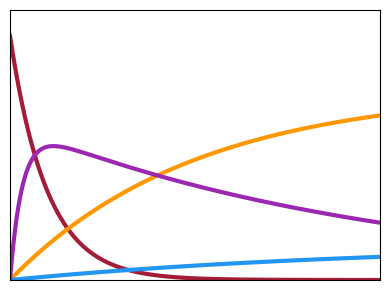

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Time axis ---
t = np.linspace(0, 0.01, 2000)

# --- Species parameters (tune these to adjust shape/scale) ---
C_total = 4.7e-3  # rough initial reactant concentration

# 1. Reactant: exponential decay
k_decay = 1000          # decay rate (s^-1)

reactant = C_total * np.exp(-k_decay * t)

# 2. Main product: fast sigmoidal rise to high yield (~80% of reactant lost)
k_prod = 200

main_product_max = 0.78 * C_total
main_product = main_product_max * (1 - np.exp(-k_prod * t))

# 3. Side product: slower sigmoid rise to lower yield (~15%)
k_side = 100
side_product_max = 0.15 * C_total
side_product = side_product_max * (1 - np.exp(-k_side * t))

# 4. Intermediate: rises quickly then decays — classic Bateman-style bump
#    Uses difference of two exponentials: A*(e^(-k1*t) - e^(-k2*t))
k1_int = 100    # formation rate
k2_int = 3000   # consumption rate
int_scale = 3.0e-3  # increase this to make the peak taller
intermediate = int_scale * (np.exp(-k1_int * t) - np.exp(-k2_int * t))
# Clamp negatives (near t=0 the fast term briefly dominates)
intermediate = np.clip(intermediate, 0, None)

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 3))


ax.plot(t, reactant,     color='#a41d36', lw=3, label='Reactant A')
ax.plot(t, main_product, color='#FF9800', lw=3, label='Main Product P')
ax.plot(t, side_product, color='#2196F3', lw=3, label='Side Product S')
ax.plot(t, intermediate, color='#9C27B0', lw=3, label='Intermediate I')

# Formatting to match MATLAB-style look
# ax.set_xlabel('Residence Time (s)', fontsize=12)
# ax.set_ylabel('Concentration (mol/cm³)', fontsize=12)
# ax.set_title('Concentration Profiles of Reacting Species', fontsize=13)
# ax.legend(loc='center right', framealpha=0.9, fontsize=10)
# ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlim(0, 0.01)
ax.set_ylim(0, 5.2e-3)

# no axis ticks
ax.set_xticks([])
ax.set_yticks([])


# Scientific notation on y-axis (×10⁻³ style)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x*1e3:.1f}'
))
# ax.set_ylabel('Concentration (×10⁻³ mol/cm³)', fontsize=12)

plt.tight_layout()
plt.savefig('kinetic_profile.svg', format='svg', bbox_inches='tight')
print("Saved to kinetic_profile.svg")
plt.show()
